# Challenge: Portfolio Optimisation

In [ ]:
import numpy as np
from autoqubo import Binarization, SamplingCompiler, SearchSpace
import yfinance as yf  #!pip install yfinance

%matplotlib inline
import matplotlib.pyplot as plt

from dynex import DynexConfig, ComputeBackend, sample_qubo

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)


/Users/topol/Dev/dynex_projects/PY-SDK-V2/.venv/lib/python3.13/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


# Real World Example (Markowitz Mean-Variance Model)

https://arxiv.org/pdf/2303.12601.pdf

In [2]:
# settings:
symbols = ["AAPL", "MSFT", "GOOG", "AMZN", "META"]
start_date = "2018-01-01"
end_date = "2024-01-01"
budget = 100

In [3]:
data = yf.download(symbols, start=start_date, end=end_date)["Close"]

[*********************100%***********************]  5 of 5 completed


In [4]:
print(data)

Ticker            AAPL        AMZN        GOOG        META        MSFT
Date                                                                  
2018-01-02   40.304169   59.450500   52.853584  180.161530   78.870369
2018-01-03   40.297157   60.209999   53.721085  183.388977   79.237427
2018-01-04   40.484325   60.479500   53.915623  183.051346   79.934822
2018-01-05   40.945259   61.457001   54.701225  185.553848   80.925873
2018-01-08   40.793186   62.343498   54.934978  186.973938   81.008438
...                ...         ...         ...         ...         ...
2023-12-22  191.609497  153.419998  141.657547  350.938599  368.236633
2023-12-26  191.065125  153.410004  141.756805  352.368622  368.315277
2023-12-27  191.164078  153.339996  140.387070  355.347748  367.735291
2023-12-28  191.589661  153.380005  140.228256  355.834381  368.924774
2023-12-29  190.550461  151.940002  139.880875  351.504639  369.671967

[1509 rows x 5 columns]


## Calculate mean returns and covariance matrix:

In [5]:
trading_days = 252; # number of trading days per year
returns = data.pct_change().dropna();
mean_daily_returns = returns.mean();
mean_annual_returns = mean_daily_returns * trading_days # annualized
cov_matrix = returns.cov();
n = len(symbols)
cov_matrix_np = np.zeros((n, n))
cov_matrix_np = np.array(cov_matrix)
cov_matrix_np = cov_matrix_np * trading_days # annualized
mean_vector_np = np.zeros(n)
mean_vector_np = np.array(mean_annual_returns)

In [6]:
print("Mean vector:")
print(mean_daily_returns*trading_days)
print()
print("Covariance matrix:")
print(cov_matrix*trading_days)

Mean vector:
Ticker
AAPL    0.309906
AMZN    0.219349
GOOG    0.211479
META    0.204932
MSFT    0.303639
dtype: float64

Covariance matrix:
Ticker      AAPL      AMZN      GOOG      META      MSFT
Ticker                                                  
AAPL    0.100343  0.069905  0.066677  0.077528  0.071554
AMZN    0.069905  0.125078  0.074557  0.091815  0.074206
GOOG    0.066677  0.074557  0.097505  0.088823  0.071861
META    0.077528  0.091815  0.088823  0.182890  0.078538
MSFT    0.071554  0.074206  0.071861  0.078538  0.090745


## Portfolio Optimisation Model:

In [7]:
def variance(x):
    """
    Variance
    """
    return x @ cov_matrix_np @ x


def mean(x):
    """
    Mean return
    """
    return x @ mean_vector_np


def constraint(x):
    """
    Budget constraint
    """
    return (x.sum() - budget) ** 2

In [8]:
A, B, C = 1, -1, 100

In [9]:
# Mean-variance portfolio optimization model
def f(x):
    return A * variance(x) + B * mean(x) + C * constraint(x)

## Create QUBO formulation

In [10]:
s = SearchSpace()
weights_vector = Binarization.get_uint_vector_type(n, n)
s.add("x", weights_vector, n * n)

qubo, offset = SamplingCompiler.generate_qubo_matrix(fitness_function=f, input_size=s.size, searchspace=s,
                                                     use_multiprocessing=False)

if SamplingCompiler.test_qubo_matrix(f, qubo, offset, search_space=s):
    print("QUBO generation successful")
else:
    print("QUBO generation failed - the objective function is not quadratic")

QUBO generation successful


In [11]:
print(qubo[:3], "offset:",offset)

[[-19900.20956283    400.40137294    800.80274588   1601.60549176
    3203.21098352    200.13980915    400.27961829    800.55923658
    1601.11847316   3202.23694632    200.13335448    400.26670896
     800.53341791   1601.06683582   3202.13367165    200.15505613
     400.31011225    800.62022451   1601.24044902   3202.48089803
     200.14310806    400.28621612    800.57243223   1601.14486447
    3202.28972893]
 [     0.         -39600.21843919   1601.60549176   3203.21098352
    6406.42196704    400.27961829    800.55923658   1601.11847316
    3202.23694632   6404.47389265    400.26670896    800.53341791
    1601.06683582   3202.13367165   6404.2673433     400.31011225
     800.62022451   1601.24044902   3202.48089803   6404.96179607
     400.28621612    800.57243223   1601.14486447   3202.28972893
    6404.57945786]
 [     0.              0.         -78399.63413251   6406.42196704
   12812.84393408    800.55923658   1601.11847316   3202.23694632
    6404.47389265  12808.9477853     8

## Compute on Dynex

In [12]:
from dynex import BQM

print("Best solutions (minimize):")

sampleset = sample_qubo(qubo, offset, num_reads=50, annealing_time=200)
print(sampleset)

INFO: [DYNEX-CPU] Timing breakdown:
INFO: [DYNEX-CPU]   Job upload:        0.28s
INFO: [DYNEX-CPU]   Time to 1st shot:  6.54s
INFO: [DYNEX-CPU]   Compute (Apollo):  6.54s
INFO: [DYNEX-CPU]   Solution download: 0.04s
INFO: [DYNEX-CPU]   Total elapsed:     6.86s
INFO: [DYNEX-CPU] Finished read after 3.189799999999998 seconds
INFO: [DYNEX-CPU] Sampleset ready with energy    0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 24     energy num_oc.
0  0  1  1  1  1  0  1  0  1  0  1  0  1  1  1  0  0 ...  1 754.496551       1
['BINARY', 1 rows, 1 samples, 25 variables]


   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 24     energy num_oc.
0  0  1  1  1  1  0  1  0  1  0  1  0  1  1  1  0  0 ...  1 754.496551       1
['BINARY', 1 rows, 1 samples, 25 variables]


In [13]:
sol = sampleset.record[0][0]
x = s.decode_dict(sol)["x"]
e = sampleset.first.energy
print(
    f"x={x}, "
    f"energy={e}, "
    f"obj={f(x)}, "
    f"constraint={constraint(x)} "
    f"obj(baseline)={f(np.repeat(100 / n, n))} ({f(x) - f(np.repeat(100 / n, n))})"
)

x=[30 10 29  0 31], energy=754.496551267337, obj=754.4965512693502, constraint=0 obj(baseline)=826.0094810459175 (-71.51292977656726)


## Plot Results

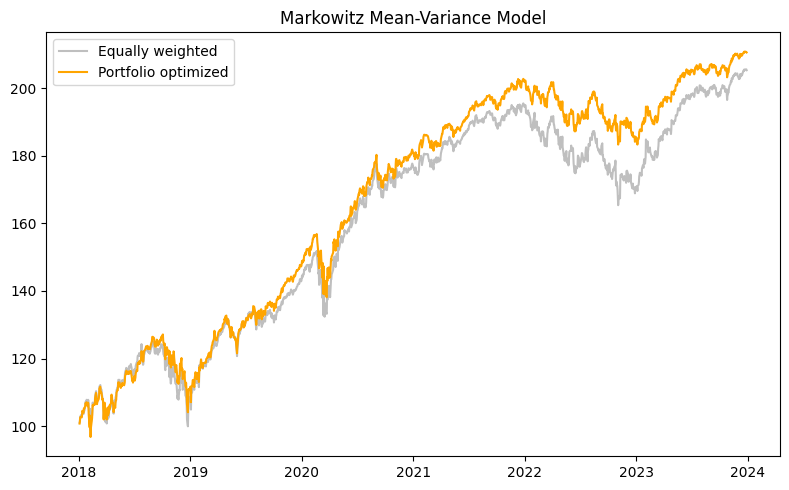

Return (equally weigthed) : 205.36639718296996 %
Return (optimized)        : 210.65011992509838 %
Improved objective by     : -71.51292977656726


In [14]:
portfolio_equally_weighted = []
portfolio_opt_weighted = []
pul = budget
pul_opt = budget
returns_np = np.array(returns)

for day in returns_np:
    # equally weighted portfolio:
    budget_day = pul
    for i in range(0, len(day)):
        asset_weight = (100 / n) / budget_day * 100
        pul += asset_weight * day[i]
    portfolio_equally_weighted.append(pul)

    # optimised weighted portfolio:
    budget_day = pul_opt
    for i in range(0, len(day)):
        asset_weight = x[i] / budget_day * 100
        pul_opt += asset_weight * day[i]
    portfolio_opt_weighted.append(pul_opt)

plt.figure(figsize=(8, 5))
plt.title("Markowitz Mean-Variance Model")
plt.plot(data.index[1:], portfolio_equally_weighted, "-", color="gray", label="Equally weighted", alpha=0.5)
plt.plot(data.index[1:], portfolio_opt_weighted, "-", color="orange", label="Portfolio optimized")
plt.legend()
plt.tight_layout()
plt.show()

print("Return (equally weigthed) :", portfolio_equally_weighted[-1] / budget * 100, "%")
print("Return (optimized)        :", portfolio_opt_weighted[-1] / budget * 100, "%")
print("Improved objective by     :", f(x) - f(np.repeat(100 / n, n)))